# Exploratory Data Analysis (EDA) - Credit Risk Model

## 1. Overview
This notebook performs exploratory data analysis on the Credit Risk dataset. The goal is to uncover patterns, identify data quality issues, and form hypotheses for feature engineering.

### Objectives:
- Overview of the Data Structure
- Summary Statistics
- Distribution of Features (Numerical & Categorical)
- Correlation Analysis
- Missing Values & Outlier Detection

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Load Data
Please ensure the dataset is placed in `data/raw/`.

In [16]:
# TODO: Update path when data is available
DATA_PATH = "../data/raw/data.csv" 

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {DATA_PATH}. Please check the path.")

Data loaded successfully. Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


## 3. Data Overview & Summary Statistics

In [17]:
# Data Types and Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [18]:
# Convert TransactionStartTime to datetime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

In [19]:
# Summary Statistics for Numerical Columns
display(df.describe())

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [20]:
# Summary Statistics for Categorical Columns
display(df.describe(include=['object']))

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935


## 4. Distribution of Features

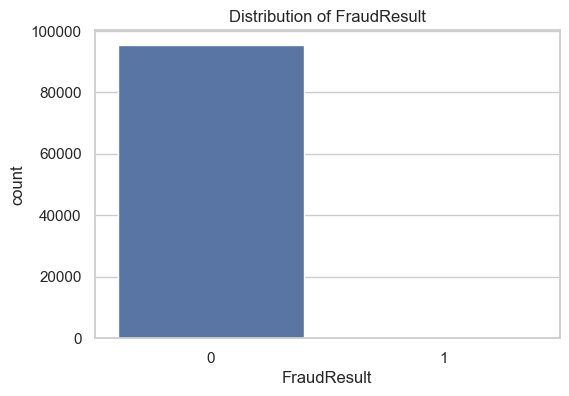

FraudResult
0    0.997982
1    0.002018
Name: proportion, dtype: float64


In [21]:
# Distribution of FraudResult (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(x='FraudResult', data=df)
plt.title('Distribution of FraudResult')
plt.show()

print(df['FraudResult'].value_counts(normalize=True))

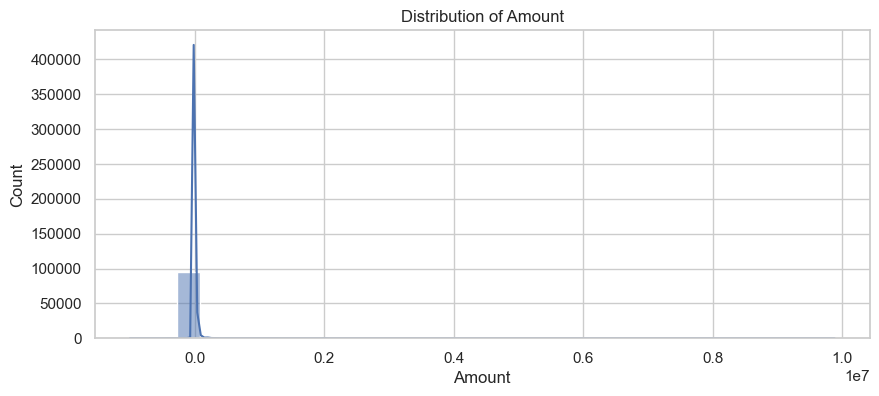

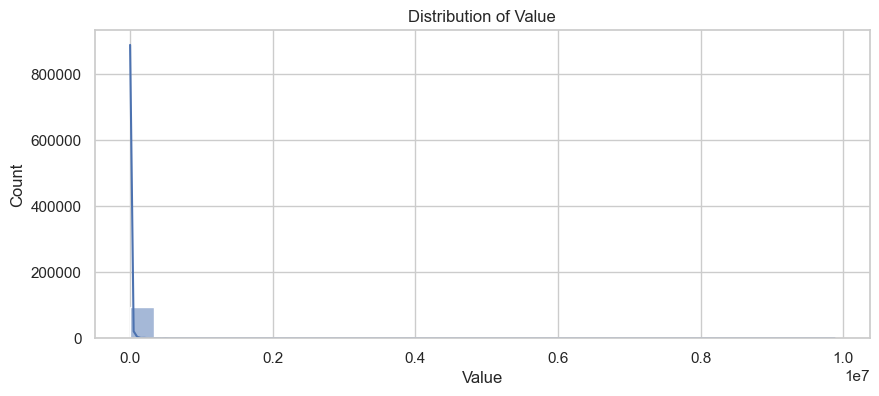

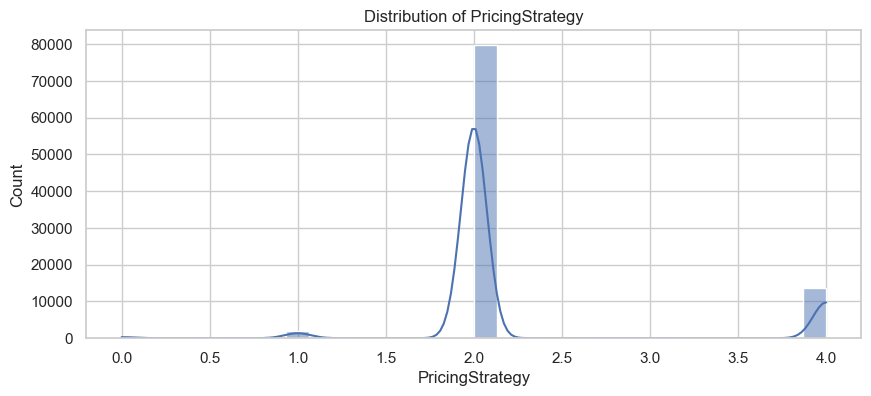

In [22]:
# Distribution of Numerical Features
numerical_cols = ['Amount', 'Value', 'PricingStrategy'] # Select key numerical columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

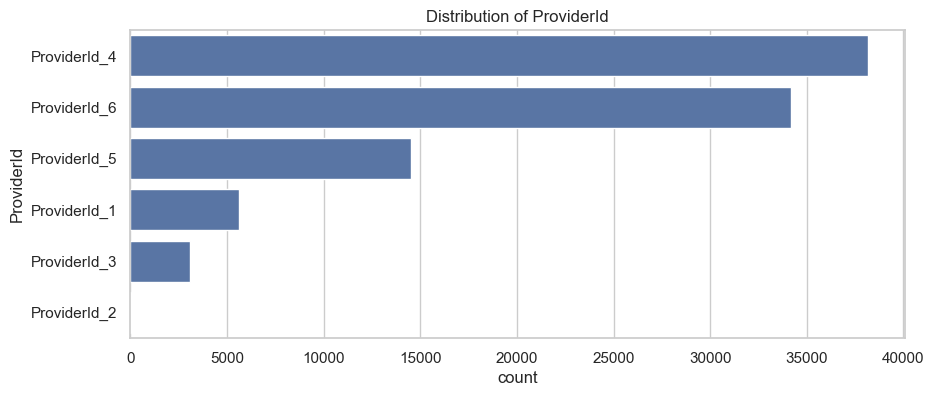

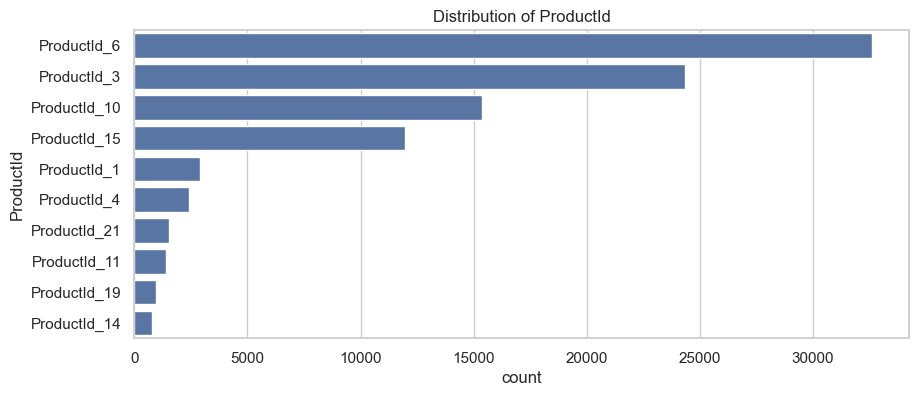

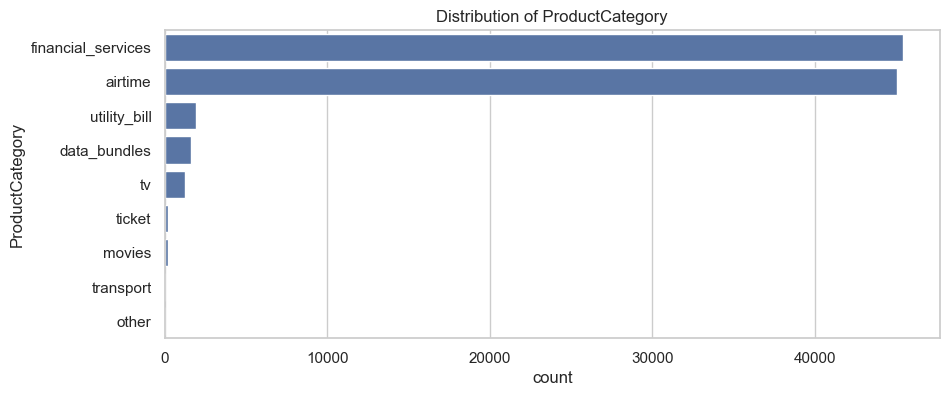

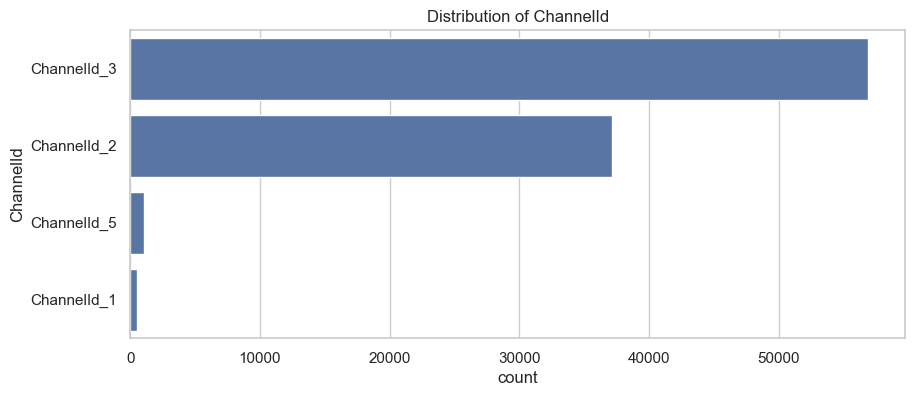

In [23]:
# Distribution of Categorical Features (Top 10 categories)
categorical_cols = ['ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().iloc[:10].index)
    plt.title(f'Distribution of {col}')
    plt.show()

## 5. Correlation Analysis

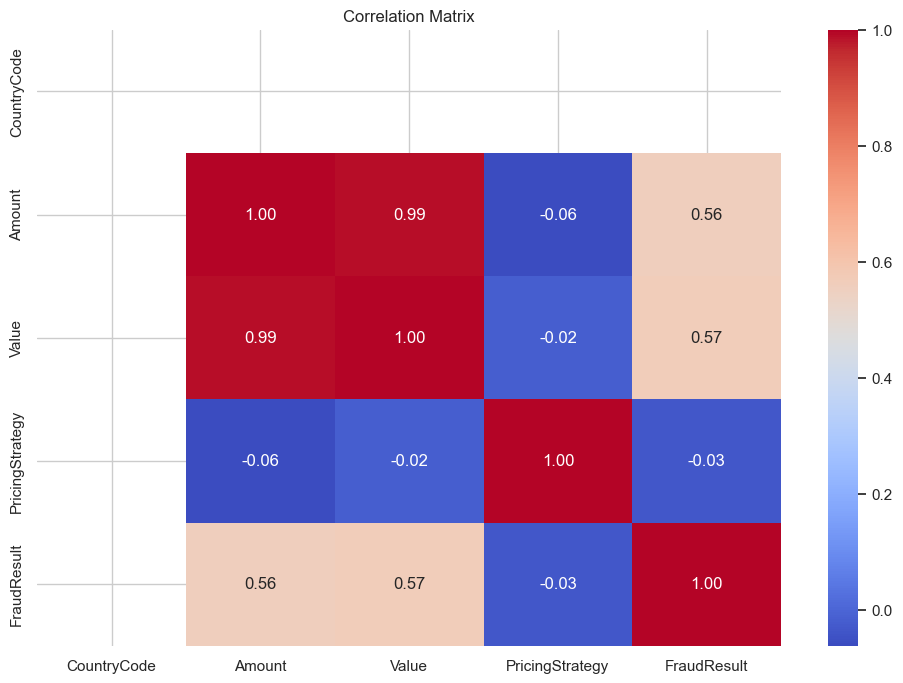

In [24]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 6. Missing Values & Outliers

In [25]:
# Missing Values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


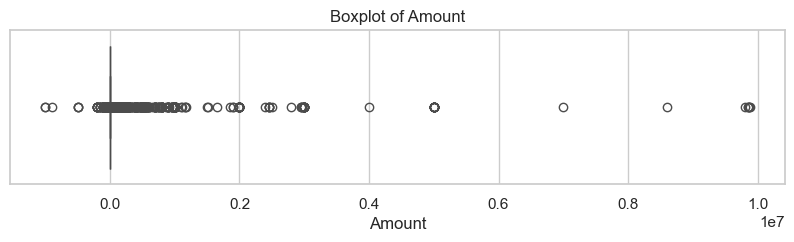

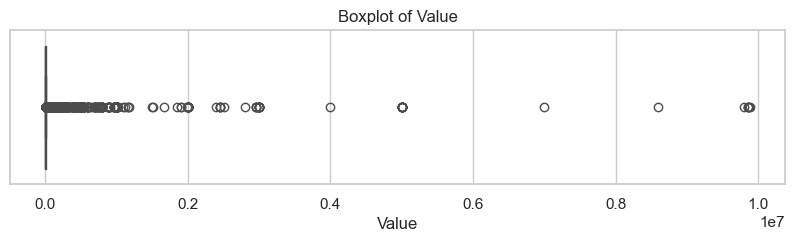

In [26]:
# Outlier Detection using Boxplots
for col in ['Amount', 'Value']:
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 7. Key Insights
Based on the analysis:


**Critical Class Imbalance Confirmed (0.2018% Fraud):**
The target variable, FraudResult, is highly imbalanced, with only 0.2018% of the 95,662 total transactions classified as fraudulent (*FraudResult = 1*). This is the most significant finding and indicates that model performance must be evaluated using robust metrics such as F1-Score, Recall, Precision, or AUC-ROC, as accuracy would be misleading.

**High Concentration of Transactional Volume:**
The majority of transactions are concentrated among a small number of entities. For example, the top *AccountId_4841* accounts for over 30,000 transactions, and *financial_services* is the dominant *ProductCategory*. This suggests that entity-based features—such as transaction count, transaction velocity, or mean and maximum transaction value per *AccountId* or *CustomerId*—will be essential for predictive modeling.

**Confirmed Directionality of Flow is a Key Feature:**
The Amount column is not just a value but represents the direction of money movement (debit or credit). The presence of negative values (credits) is expected and not an outlier issue, but a feature that must be explicitly utilized. Value can be used to represent transaction magnitude, and a new binary feature, Is_Credit = (Amount < 0), should be created to capture the direction of the flow, which is a powerful feature in fraud detection.

